# Employee Turnover Analytics

## Course Assessment Project – IG AI: Machine Learning

### Created by: Asma I. Punekar

##### As the ML Developer assigned to the HR Department, you have been asked to create ML Programs to
##### 1.	Perform data quality check by checking for missing values if any.
##### 2.	Understand what factors contributed most to employee turnover by EDA.
##### 3.	Perform clustering of Employees who left based on their satisfaction and evaluation.
##### 4.	Handle the left Class Imbalance using SMOTE technique.
##### 5.	Perform k-fold cross-validation model training and evaluate performance. 
##### 6.	Identify the best model and justify the evaluation metrics used. 
##### 7.	Suggest various retention strategies for targeted employees.


In [1]:
# Import librabries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)



In [2]:
# Read Data
df = pd.read_excel('turnover.xlsx')

In [3]:
df.tail(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low
14998,0.37,0.52,2,158,3,0,1,0,support,low


## 1. Steps for Data Quality Check

### Shape of dataset,data types,missing and unique values in column, basic descriptive statistics, finding duplicate rows in dataset

In [4]:
df.shape

(14999, 10)

In [5]:
df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                     object
salary                    object
dtype: object

In [6]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [7]:
df.duplicated().sum()

3008

In [8]:
df = df.drop_duplicates()

In [9]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [10]:
df['sales'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [11]:
df['salary'].unique()


array(['low', 'medium', 'high'], dtype=object)

In [12]:
df = df.rename(columns={'sales': 'dept'})

In [13]:
df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   dept                   11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


## Findings

#### *  Missing values:  None (all columns complete). So no imputation.
#### *  Duplicates:  About 3,008 duplicate rows exist. Duplicated rows are removed from dataset.
#### *  Numeric features:  satisfaction_level, last_evaluation, number_project, average_montly_hours, time_spend_company, Work_accident, promotion_last_5years.
#### *  Categorical features: sales (department), salary.
#### *  Target column: left.

## 2.	Understand what factors contributed most to employee turnover by EDA.

In [15]:
df['left'].value_counts(normalize=True)

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64

In [16]:
# Group the dataset by 'left' column (0 = stayed, 1 = left)
# Then calculate the mean values of key features for each group
df.groupby('left')[['satisfaction_level','last_evaluation',
                    'number_project','average_montly_hours',
                    'time_spend_company']].mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company
left,,,,,
0,0.667365,0.715667,3.786800,198.94270,3.262000
1,0.440271,0.721783,3.883476,208.16223,3.881467


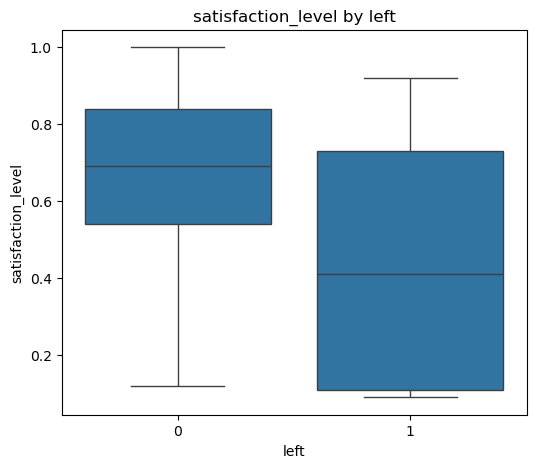

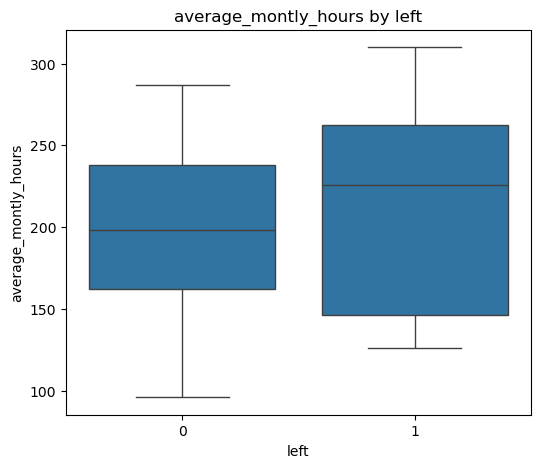

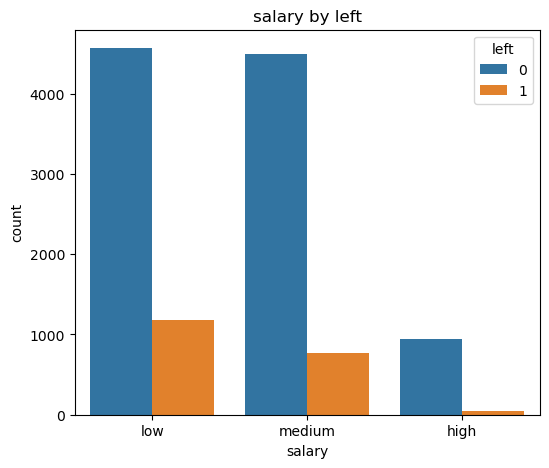

In [17]:
plt.figure(figsize=(6,5))
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.title("satisfaction_level by left")
plt.show()
plt.figure(figsize=(6,5))
sns.boxplot(x='left', y='average_montly_hours', data=df)
plt.title("average_montly_hours by left")
plt.show()
plt.figure(figsize=(6,5))
sns.countplot(x='salary', hue='left', data=df)
plt.title("salary by left")
plt.show()

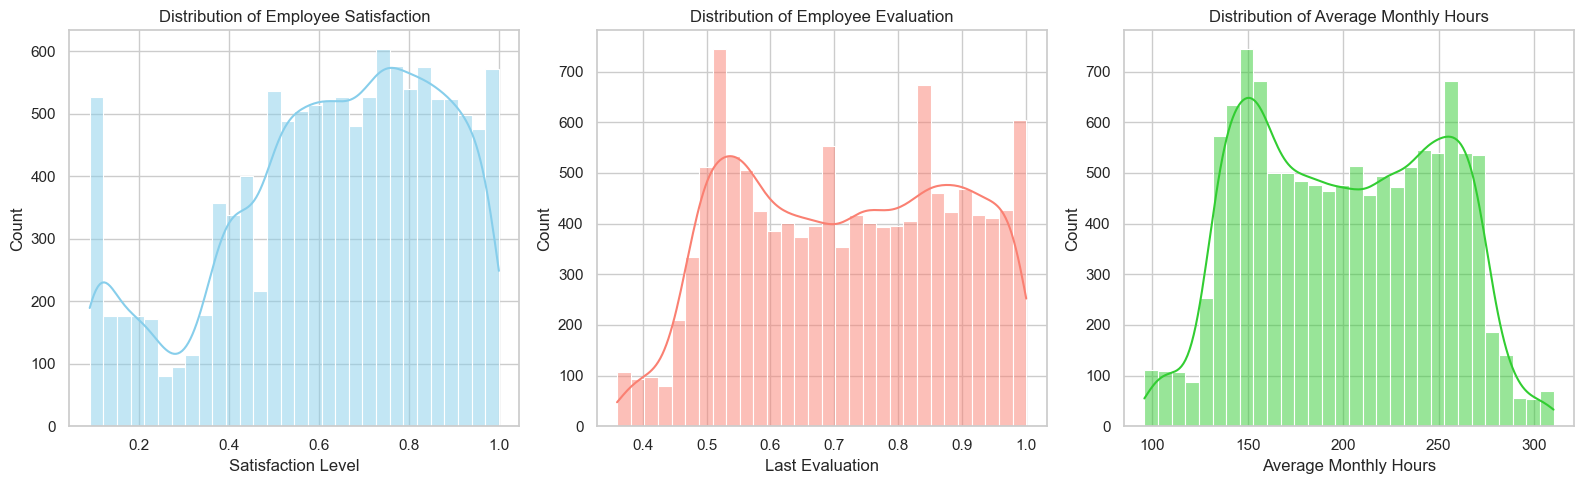

In [18]:
sns.set(style="whitegrid")

# Create figure with subplots
plt.figure(figsize=(16,5))

# 1. Distribution of Employee Satisfaction
plt.subplot(1,3,1)
sns.histplot(df['satisfaction_level'], kde=True, color="skyblue", bins=30)
plt.title("Distribution of Employee Satisfaction")
plt.xlabel("Satisfaction Level")

# 2. Distribution of Employee Evaluation
plt.subplot(1,3,2)
sns.histplot(df['last_evaluation'], kde=True, color="salmon", bins=30)
plt.title("Distribution of Employee Evaluation")
plt.xlabel("Last Evaluation")

# 3. Distribution of Average Monthly Hours
plt.subplot(1,3,3)
sns.histplot(df['average_montly_hours'], kde=True, color="limegreen", bins=30)
plt.title("Distribution of Average Monthly Hours")
plt.xlabel("Average Monthly Hours")

plt.tight_layout()
plt.show()

### Findings
#### Satisfaction: often bimodal (very low and very high peaks : indicates unhappy and highly satisfied employees).
#### Evaluation: tends to cluster near low or high performance.
#### Monthly Hours: may show distinct groups (underworked vs overworked).

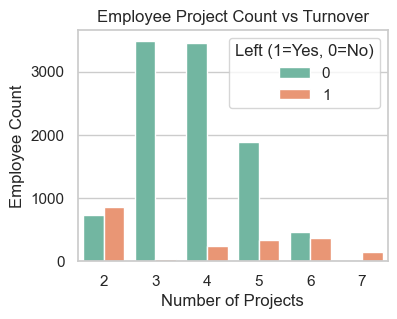

In [19]:
plt.figure(figsize=(4,3))
sns.countplot(x="number_project", hue="left", data=df, palette="Set2")

plt.title("Employee Project Count vs Turnover")
plt.xlabel("Number of Projects")
plt.ylabel("Employee Count")
plt.legend(title="Left (1=Yes, 0=No)")
plt.show()

### Findings:
##### 1 Low project count (2 or fewer):
#####   Many employees with fewer projects tend to leave : likely due to boredom or lack of engagement.
##### 2 Moderate project count (3–4):
#####   Employees in this range are less likely to leave : they seem to have a balanced workload.
##### 3 High project count (6–7):
#####   A large proportion of employees with many projects leave : indicating burnout or overwork.
##### 4 Sweet spot (4–5 projects):
#####   Employees in this range usually stay longer : suggesting that optimal engagement reduces turnover.

In [20]:
# Percentage of employees who stayed/left in each department
pd.crosstab(df['dept'], df['left'], normalize='index') * 100

left,0,1
dept,,
IT,83.811475,16.188525
RandD,87.752161,12.247839
accounting,82.447665,17.552335
hr,81.198003,18.801997
management,88.073394,11.926606
marketing,83.358098,16.641902
product_mng,83.965015,16.034985
sales,83.019450,16.980550
support,82.866557,17.133443


In [21]:
# Convert the 'salary' column from categorical values ('low', 'medium', 'high')
# to numeric codes: low → 1, medium → 2, high → 3
# Perform one-hot encoding on the 'dept' column
# Each department becomes a new binary column (0 or 1)
df['salary'] = df['salary'].map({'low':1, 'medium':2, 'high':3})
df = pd.get_dummies(df, columns=['dept'], drop_first=True, dtype =int)

In [22]:
df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.38,0.53,2,157,3,0,1,0,1,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,2,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,2,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,1,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,1,0,0,0,0,0,0,1,0,0


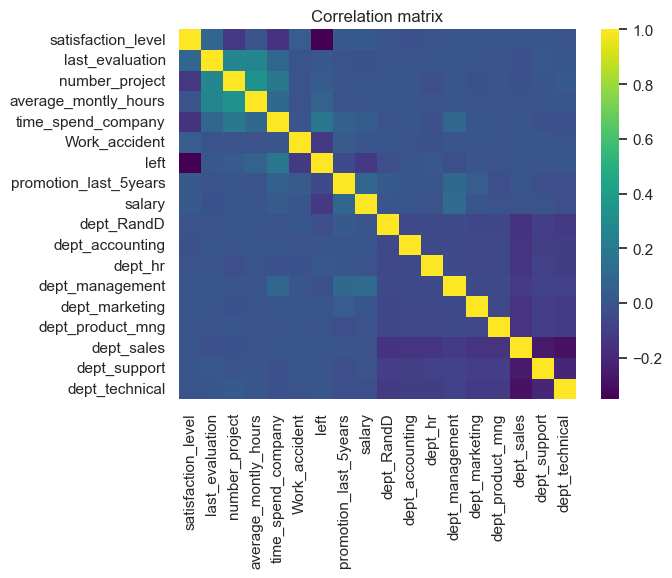

In [23]:
# Compute pairwise correlation between all numeric columns in the DataFrame
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='viridis')
plt.title("Correlation matrix")
plt.show()

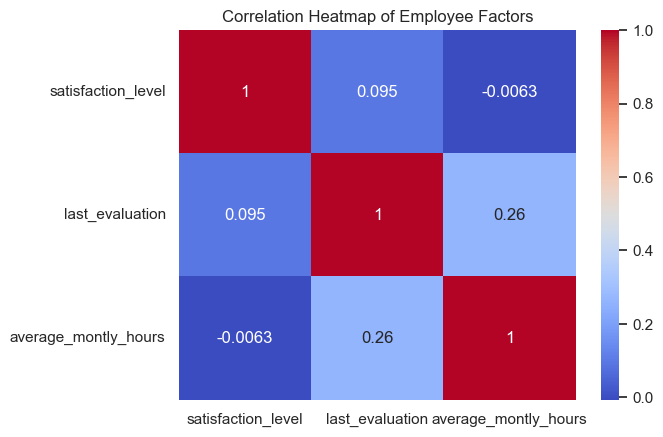

In [24]:
# Calculate correlation matrix among satisfaction_level, last_evaluation, and average_montly_hours
corr = df[['satisfaction_level','last_evaluation','average_montly_hours']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Employee Factors")
plt.show()

## Findings

####  * Satisfaction level: Satisfaction: often bimodal (very low and very high peaks : indicates unhappy and highly satisfied employees)              low satisfaction is the strongest predictor of leaving.
####  * Average monthly hours: both very low(underworked) and very high(overworked) hours correlate with turnover.
####  * Number of projects: too few or too many projects : higher chance of leaving.
####  * Salary: employees with low salary leave much more.
####  * Department (sales/tech/support, etc.): some departments may have higher attrition.
####  * Promotions: very few employees with promotions leave.
####  * Evaluation: tends to cluster near low or high performance.


# 3.	Perform clustering of Employees who left based on their satisfaction and evaluation.

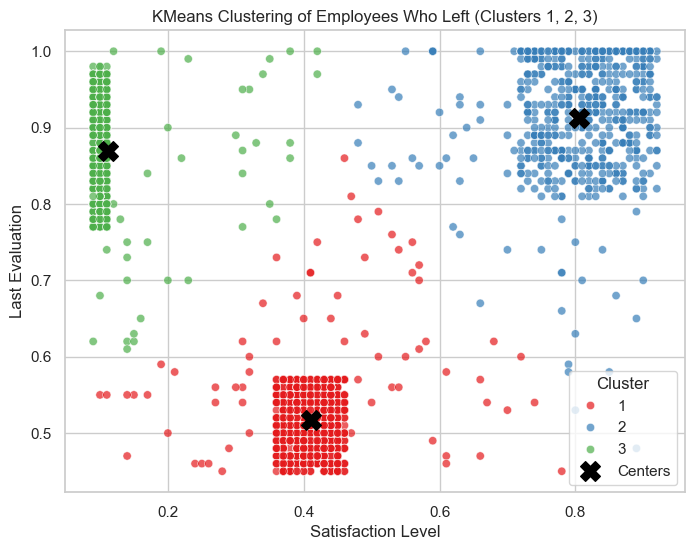

In [25]:
# Step 1: Filter only employees who left
left_df = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']].copy()

# Step 2: Apply KMeans (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
left_df['cluster'] = kmeans.fit_predict(left_df[['satisfaction_level', 'last_evaluation']])

# Shift labels to start from 1 instead of 0
left_df['cluster'] = left_df['cluster'] + 1

# Step 3: Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='satisfaction_level', 
    y='last_evaluation', 
    hue='cluster', 
    data=left_df, 
    palette='Set1', 
    alpha=0.7
)
plt.scatter(
    kmeans.cluster_centers_[:,0], 
    kmeans.cluster_centers_[:,1], 
    s=200, c='black', marker='X', label='Centers'
)
plt.title("KMeans Clustering of Employees Who Left (Clusters 1, 2, 3)")
plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation")
plt.legend(title="Cluster")
plt.show()

In [26]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['satisfaction_level', 'last_evaluation'])
centers.index = centers.index + 1  # shift index to match cluster labels (1,2,3)

print("Cluster Centers:\n", centers)

Cluster Centers:
    satisfaction_level  last_evaluation
1            0.410133         0.517195
2            0.805874         0.912577
3            0.111199         0.869064


##### Cluster 1 – Low Satisfaction, Moderate Evaluation:
##### Employees with very low satisfaction but not necessarily poor evaluation.
##### These are disengaged employees : left because they were unhappy despite okay performance.
##### Cluster 2 – High Satisfaction, High Evaluation:
##### Strange group: satisfied and evaluated well, but still left.
##### Could be due to external opportunities (better offers, promotions elsewhere, personal reasons).
##### Cluster 3 – High Evaluation, Low/Medium Satisfaction:
##### Employees with good performance evaluations but low satisfaction.
##### Likely high performers leaving due to frustration / overwork / lack of recognition.


# 4.	Handle the left Class Imbalance using SMOTE technique.

In [27]:
y = df['left']   # Target column
X = df.drop('left', axis=1)  # All features except target


In [28]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.38,0.53,2,157,3,0,1,0,1,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,2,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,2,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,1,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,1,0,0,0,0,0,0,1,0,0


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# Check class balance
print("\nClass distribution in Train set:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in Test set:\n", y_test.value_counts(normalize=True))

Train shape: (9592, 17) (9592,)
Test shape: (2399, 17) (2399,)

Class distribution in Train set:
 left
0    0.833924
1    0.166076
Name: proportion, dtype: float64

Class distribution in Test set:
 left
0    0.834098
1    0.165902
Name: proportion, dtype: float64


In [30]:
smote = SMOTE(random_state=123)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE (Train):", Counter(y_train))
print("After SMOTE (Train):", Counter(y_train_resampled))

Before SMOTE (Train): Counter({0: 7999, 1: 1593})
After SMOTE (Train): Counter({0: 7999, 1: 7999})


In [31]:
print(y_train.head())
print(y_train.unique())

9492     0
11555    0
11301    0
5578     0
6241     0
Name: left, dtype: int64
[0 1]


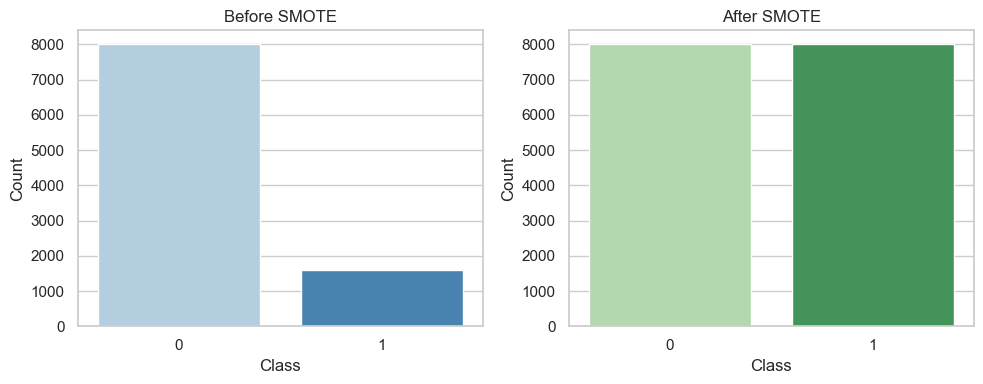

In [32]:
# Convert to DataFrames for easy plotting
before_df = pd.DataFrame({"Class": y_train})
after_df  = pd.DataFrame({"Class": y_train_resampled})

# Create side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
sns.countplot(x="Class", data=before_df, ax=ax[0], palette="Blues")
ax[0].set_title("Before SMOTE")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

# After SMOTE
sns.countplot(x="Class", data=after_df, ax=ax[1], palette="Greens")
ax[1].set_title("After SMOTE")
ax[1].set_xlabel("Class")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

#	5. Train a model and plot the classification report.
##  5.1 Train a Logistic Regression model and apply a 5-Fold CV and plot the classification report.

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.82      7999
           1       0.81      0.85      0.83      7999

    accuracy                           0.83     15998
   macro avg       0.83      0.83      0.83     15998
weighted avg       0.83      0.83      0.83     15998



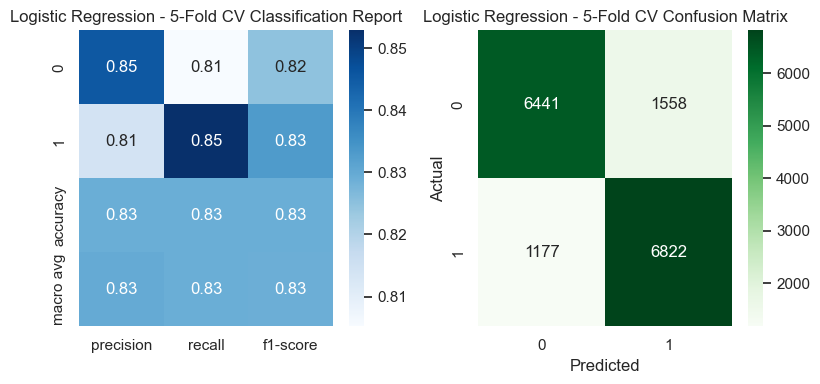

In [33]:
log_reg = LogisticRegression(max_iter=1000, random_state=123)

# Stratified KFold to maintain class distribution
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Cross-validation predictions
y_pred_cv = cross_val_predict(log_reg, X_train_resampled, y_train_resampled, cv=cv)

# Classification report
report = classification_report(y_train_resampled, y_pred_cv, output_dict=True)
print("Classification Report:\n", classification_report(y_train_resampled, y_pred_cv))

# Convert report to DataFrame for heatmap
df_report = pd.DataFrame(report).transpose()

# -----------------------
# Plot both graphs side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Classification report heatmap
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f", ax=axes[0])
axes[0].set_title("Logistic Regression - 5-Fold CV Classification Report")

# Confusion Matrix heatmap
cm = confusion_matrix(y_train_resampled, y_pred_cv)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=[0,1], yticklabels=[0,1], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Logistic Regression - 5-Fold CV Confusion Matrix")

plt.tight_layout()
plt.show()

## 5.2 Train a Random Forest Classifier model and apply the 5-Fold CV and plot the classification report.

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98      7999
           1       0.99      0.96      0.97      7999

    accuracy                           0.98     15998
   macro avg       0.98      0.98      0.98     15998
weighted avg       0.98      0.98      0.98     15998



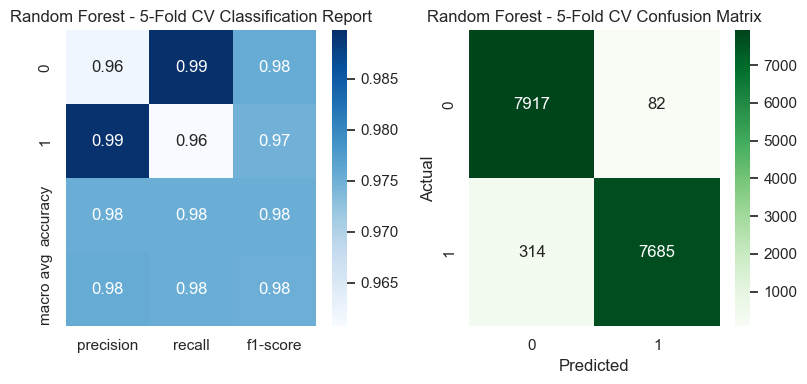

In [34]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=123)

# Stratified KFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Cross-validation predictions
y_pred_cv_rf = cross_val_predict(rf_model, X_train_resampled, y_train_resampled, cv=cv)

# -----------------------
# Classification Report
# -----------------------
report_rf = classification_report(y_train_resampled, y_pred_cv_rf, output_dict=True)
print("Classification Report:\n", classification_report(y_train_resampled, y_pred_cv_rf))

# Convert to DataFrame
df_report_rf = pd.DataFrame(report_rf).transpose()

# -----------------------
# Plot classification report + confusion matrix side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(8,4))

# Classification Report Heatmap
sns.heatmap(df_report_rf.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f", ax=axes[0])
axes[0].set_title("Random Forest - 5-Fold CV Classification Report")

# Confusion Matrix Heatmap
cm_rf = confusion_matrix(y_train_resampled, y_pred_cv_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=[0,1], yticklabels=[0,1], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Random Forest - 5-Fold CV Confusion Matrix")

plt.tight_layout()
plt.show()

## 5.3.Train a  Gradient Boosting Classifier model and apply the 5-Fold CV and plot the classification report.

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      7999
           1       0.98      0.94      0.96      7999

    accuracy                           0.96     15998
   macro avg       0.96      0.96      0.96     15998
weighted avg       0.96      0.96      0.96     15998



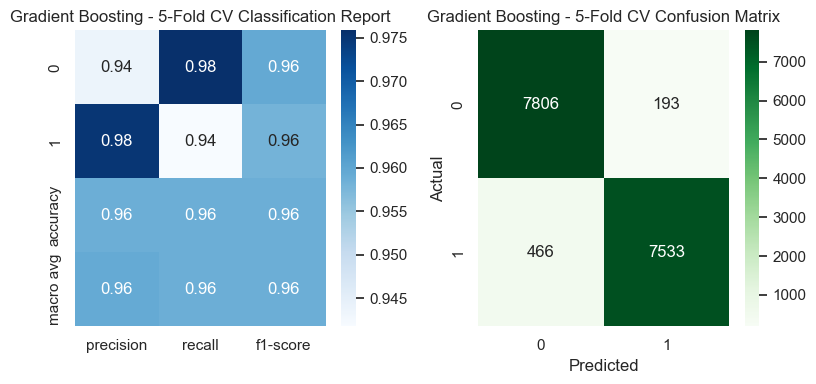

In [35]:

gb_model = GradientBoostingClassifier(random_state=123)

# Stratified KFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Cross-validation predictions
y_pred_cv_gb = cross_val_predict(gb_model, X_train_resampled, y_train_resampled, cv=cv)

# -----------------------
# Classification Report
# -----------------------
report_gb = classification_report(y_train_resampled, y_pred_cv_gb, output_dict=True)
print("Classification Report:\n", classification_report(y_train_resampled, y_pred_cv_gb))

# Convert to DataFrame
df_report_gb = pd.DataFrame(report_gb).transpose()

# -----------------------
# Plot classification report + confusion matrix side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(8,4))

# Classification Report Heatmap
sns.heatmap(df_report_gb.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f", ax=axes[0])
axes[0].set_title("Gradient Boosting - 5-Fold CV Classification Report")

# Confusion Matrix Heatmap
cm_gb = confusion_matrix(y_train_resampled, y_pred_cv_gb)
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Greens", xticklabels=[0,1], yticklabels=[0,1], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Gradient Boosting - 5-Fold CV Confusion Matrix")

plt.tight_layout()
plt.show()

# 6.	Identify the best model and justify the evaluation metrics used. 
## 6.1.	Find the ROC/AUC for each model and plot the ROC curve.


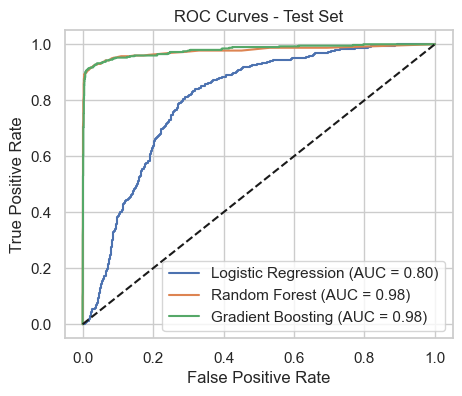

In [36]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=123),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=123),
    "Gradient Boosting": GradientBoostingClassifier(random_state=123)
}

plt.figure(figsize=(5, 4))

# Loop through models
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot formatting
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set")
plt.legend(loc="lower right")
plt.show()

# 6.2.	Find the confusion matrix for each of the models.
## 6.3.	From the confusion matrix, explain which metric needs to be used- Recall or Precision?


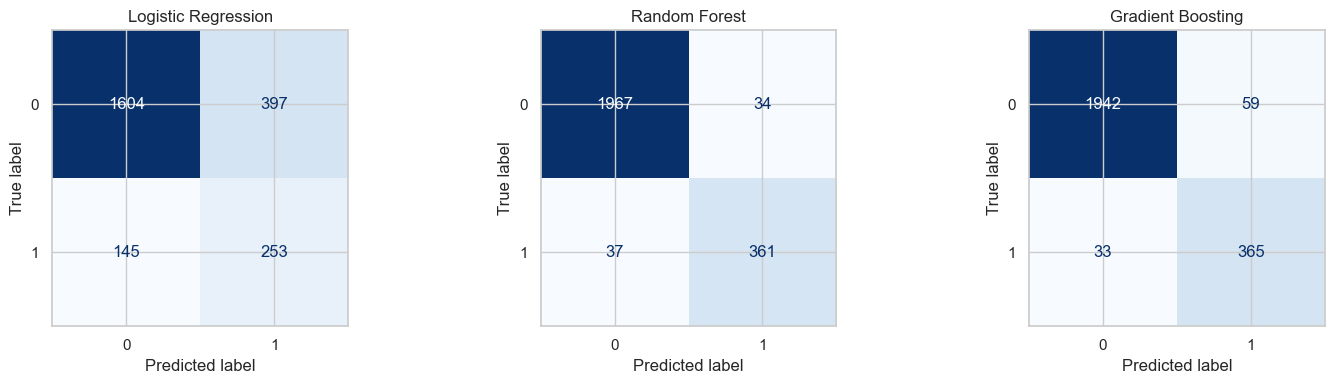

In [37]:
plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test)  # predicted class labels
    cm = confusion_matrix(y_test, y_pred)

    # Display each confusion matrix
    plt.subplot(1, 3, i)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=plt.gca(), cmap="Blues", colorbar=False)
    plt.title(name)

plt.tight_layout()
plt.show()

In [38]:
# Models dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=123),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=123),
    "Gradient Boosting": GradientBoostingClassifier(random_state=123)
}

# List to store rows
rows = []

for name, model in models.items():
    # Train on resampled training set
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Recall for class 1
    recall_class1 = report['1']['recall']
    
    rows.append({
        "Model": name,
        "Recall_Class_1": round(recall_class1, 3)
    })

# Convert list of dicts to DataFrame
recall_df = pd.DataFrame(rows)

recall_df

,Model,Recall_Class_1
0,Logistic Regression,0.636
1,Random Forest,0.907
2,Gradient Boosting,0.917


## Findings:
#### Recall is the critical metric here because we care about detecting as many actual leavers as possible.
#### Based on Recall, Gradient Boosting is the best model, closely followed by Random Forest.
#### Logistic Regression is comparatively weaker in catching employees who will leave.

# 7.	Suggest various retention strategies for targeted employees.
## 7.1.	Using the best model, predict the probability of employee turnover in the test data.


In [39]:
# Use the best model (replace with the actual best if known)
best_model = GradientBoostingClassifier(random_state=123)
best_model.fit(X_train_resampled, y_train_resampled)

# Predict probability of leaving (class 1) on test set
y_proba_test = best_model.predict_proba(X_test)[:, 1]  # probabilities for class 1

# Add probabilities to a DataFrame along with employee index
employee_probs = X_test.copy()
employee_probs['Turnover_Probability'] = y_proba_test
employee_probs.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical,Turnover_Probability
8578,0.82,0.95,6,191,6,0,0,2,0,1,0,0,0,0,0,0,0,0.181149
5756,0.18,0.86,5,267,4,0,0,2,0,1,0,0,0,0,0,0,0,0.512005
3994,0.63,0.98,4,160,2,0,0,2,0,0,0,0,0,0,1,0,0,0.034384
1784,0.43,0.51,2,149,3,1,0,2,0,1,0,0,0,0,0,0,0,0.820651
10508,0.51,0.98,4,245,3,0,0,2,0,0,0,0,0,0,0,1,0,0.050588


## .2.	Based on the below probability score range, categorize the employees into four zones 
## ■	Safe Zone (Green) (Score < 20%)
## ■	Low Risk Zone (Yellow) (20% < Score < 60%)


In [40]:
# Function to assign zone based on probability
def assign_zone(prob):
    if prob < 0.2:
        return "Safe Zone (Green)"
    elif 0.2 <= prob < 0.6:
        return "Low Risk Zone (Yellow)"
    elif 0.6 <= prob < 0.9:
        return "Medium Risk Zone (Orange)"
    else:
        return "High Risk Zone (Red)"

# Apply function to categorize employees
employee_probs['Risk_Zone'] = employee_probs['Turnover_Probability'].apply(assign_zone)

# Count of employees in each zone
zone_counts = employee_probs['Risk_Zone'].value_counts()
print(zone_counts)

# Show head of categorized employees
employee_probs.head()


Risk_Zone
Safe Zone (Green)            1831
High Risk Zone (Red)          329
Low Risk Zone (Yellow)        166
Medium Risk Zone (Orange)      73
Name: count, dtype: int64


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical,Turnover_Probability,Risk_Zone
8578,0.82,0.95,6,191,6,0,0,2,0,1,0,0,0,0,0,0,0,0.181149,Safe Zone (Green)
5756,0.18,0.86,5,267,4,0,0,2,0,1,0,0,0,0,0,0,0,0.512005,Low Risk Zone (Yellow)
3994,0.63,0.98,4,160,2,0,0,2,0,0,0,0,0,0,1,0,0,0.034384,Safe Zone (Green)
1784,0.43,0.51,2,149,3,1,0,2,0,1,0,0,0,0,0,0,0,0.820651,Medium Risk Zone (Orange)
10508,0.51,0.98,4,245,3,0,0,2,0,0,0,0,0,0,0,1,0,0.050588,Safe Zone (Green)


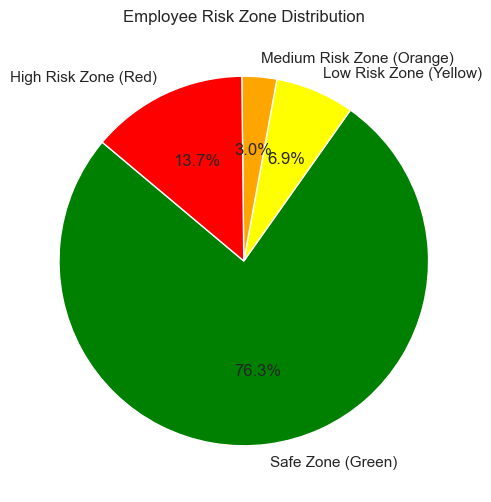

In [41]:
# Count of employees in each zone
# Recount employees in the correct order
zone_order = ["Safe Zone (Green)", "Low Risk Zone (Yellow)", "Medium Risk Zone (Orange)", "High Risk Zone (Red)"]
colors = ['green','yellow','orange','red']
zone_counts_ordered = employee_probs['Risk_Zone'].value_counts().reindex(zone_order)

# -----------------------
# Pie chart with correct colors
# -----------------------
plt.figure(figsize=(6,6))
plt.pie(
    zone_counts_ordered.values, 
    labels=zone_counts_ordered.index, 
    autopct='%1.1f%%', 
    colors=colors, 
    startangle=140
)
plt.title("Employee Risk Zone Distribution")
plt.show()



## Findings
##### Safe Zone dominates: overall workforce is stable.

##### High Risk Zone is significant enough to warrant HR action.

##### Low & Medium Risk Zones indicate employees who may leave in the near future if engagement is low.

##### This categorization can help prioritize retention strategies effectively.